# Vector Fields & Sky Kinematics

The sky moves over time. Stars stream past the Sun, quasars appear to slowly drift due to the Galaxy's
pull on the solar system, reference frames rotate subtly against each other —
and ground stations, riding the turning Earth, see it all. This
tutorial is about putting *motion and geometry* on sky maps: arrow fields
that respect the projection, the vector-spherical-harmonic language that
describes systematic patterns in them, and the co-visibility regions that say
which sky a network of stations shares.

It comes in two halves. The **kinematics half** (§2–6) draws vector fields
with `plot_sky_vectors` and `plot_displacement`, introduces the VSH modes,
and ends by measuring the Sun's own motion from a CSV of naked-eye stars. The
**networks half** (§7–8) builds station visibility caps, intersects them,
and finishes by sorting the real ICRF3 calibrator list against a global VLBI
array. As everywhere in this series, each piece answers two questions: *how
do I show my data this way?* and *how do I adjust it?*

The real data anchoring both halves ships with the repository: the 4992
naked-eye stars of the Hipparcos catalog with their proper motions, and the
303 defining sources of ICRF3.

## Contents

1. [The moving sky](#1.-The-moving-sky)
2. [Vector fields](#2.-Vector-fields)
3. [Displacement arrows](#3.-Displacement-arrows)
4. [Vector spherical harmonics](#4.-Vector-spherical-harmonics)
5. [Fitting a VSH model](#5.-Fitting-a-VSH-model)
6. [The solar apex from naked-eye stars](#6.-The-solar-apex-from-naked-eye-stars)
7. [The co-visible sky](#7.-The-co-visible-sky)
8. [Planning a VLBI session](#8.-Planning-a-VLBI-session)
9. [Where to go next](#9.-Where-to-go-next)

In [1]:
import matplotlib as mpl
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from matplotlib.colors import LinearSegmentedColormap, to_rgb

import skyplothelper as sph

# base='structural' applies just the structural style layer (frame and tick
# geometry), leaving colors and fonts to whatever theme is active — so the same
# code renders correctly under both the light and dark documentation themes.
sph.set_style(base="structural")

# Data series pull from the 'uranometria' cycle palette (dual-mode: reads on both
# light and dark pages); decoration adapts via the annotation palettes below.
C = sph.CYCLE_PALETTES["uranometria"]["colors"]


# Decoration colors adapt to the active theme: read the figure background and
# pick the matching annotation palette (accents, labels, grids, ...).
def annotation_palette():
    r, g, b = to_rgb(mpl.rcParams["figure.facecolor"])
    return sph.ANNOTATION_PALETTES["dark" if (0.299 * r + 0.587 * g + 0.114 * b) < 0.5
                                   else "publication"]


# Magnitude-colored arrows use sph's bundled colormaps, trimmed to their
# saturated body — the near-white top end (made for image display) would wash
# out the fastest arrows against a light page.
def arrow_cmap(name, lo=0.12, hi=0.85):
    base = sph.get_colormap(name)
    return LinearSegmentedColormap.from_list(
        f"{name}_arrows", base(np.linspace(lo, hi, 256)))


# Most figures here live on an all-sky Aitoff frame; one tiny wrapper saves
# repeating the figure size. (The frame's default all-sky tick labels are
# already the terse style we want — restyling them is the Decorating Frames
# tutorial's story.)
def allsky(subplot=111, fig=None, center=180, frame="ICRS", figsize=(11, 5.5), **kw):
    if fig is None:
        fig = plt.figure(figsize=figsize)
    ax = sph.make_wcs_frame(subplot, projection="AIT", center=center,
                            frame=frame, fig=fig, **kw)
    return fig, ax


# To show an analytic field we need sample points. A plain lon/lat mesh packs
# far too many of them around the poles (the meridians converge), so the arrows
# there pile into an unreadable rosette. Thinning the longitudes by cos(lat)
# samples the sphere roughly evenly instead.
def sphere_grid(n_lat=11, lat_max=78.0, dlon=16.0):
    lons, lats = [], []
    for lat in np.linspace(-lat_max, lat_max, n_lat):
        n = max(4, round(360.0 * np.cos(np.radians(lat)) / dlon))
        lons.append(np.linspace(0.0, 360.0, n, endpoint=False))
        lats.append(np.full(n, lat))
    return np.concatenate(lons), np.concatenate(lats)


# The real proper-motion catalog used throughout: every naked-eye star (V < 6)
# in the Hipparcos main catalog with complete astrometry. pmRA is the usual
# tabulated convention, mu_alpha * cos(delta), in mas/yr.
hip = Table.read("../../examples/data/hipparcos_bright_pm.csv")
hip_pm = np.hypot(hip["pmRA"], hip["pmDE"])
len(hip)

4992

## 1. The moving sky

Even the quasars appear to move (slightly). The solar system is moving around the Galaxy, and
that acceleration aberrates the light of everything we see: the apparent
position of every distant source drifts toward the Galactic center by about
**5 microarcseconds per year**. It took the combined precision of VLBI
geodesy (Titov & Lambert 2013) and Gaia (Gaia Collaboration: Klioner et al.
2021, who measured 5.05 ± 0.35 μas/yr) to detect — and it is a *perfect
dipole*, the cleanest systematic vector field in the sky.

One line of the VSH machinery from §4 generates it, and `plot_sky_vectors`
draws it — with the arrows exaggerated by a factor of a few billion, and
colored by how fast each patch of sky drifts:

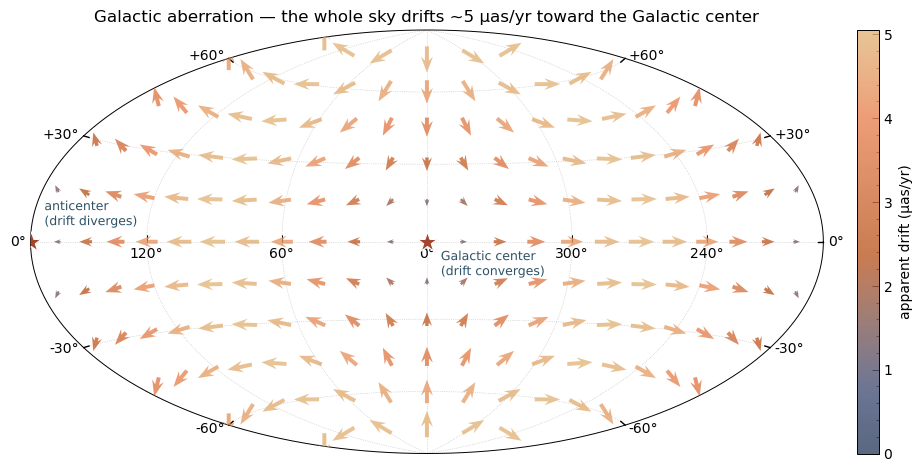

In [2]:
glon, glat = sphere_grid(n_lat=11, lat_max=75.0, dlon=15.0)

# The aberration drift: a pure VSH glide of 5.05 uas/yr toward the Galactic
# center — which is lon = 0 in Galactic coordinates, so it's all in D_1.
dlon, dlat = sph.vsh_field(glon, glat, {"D_1": 5.05})

fig, ax = allsky(frame="galactic", center=0)
pal = annotation_palette()
res = sph.plot_sky_vectors(ax, glon, glat, dlon, dlat,
                           units="uas", scale="auto", auto_target_deg=9.0,
                           width=0.005, color_by_magnitude=True,
                           cmap=arrow_cmap("dusk", hi=0.72),
                           add_colorbar=True, cbar_label="apparent drift (μas/yr)")

for lon_c, name, off in [(0, "Galactic center\n(drift converges)", (10, -24)),
                         (180, "anticenter\n(drift diverges)", (10, 12))]:
    ax.scatter(lon_c, 0, transform=ax.get_transform("world"), marker="*",
               s=230, color=pal["accent"], edgecolor=pal["fig_bg"],
               linewidth=0.8, zorder=6)
    ax.annotate(name, ax.wcs.world_to_pixel_values(lon_c, 0), xytext=off,
                textcoords="offset points", fontsize=9, color=pal["label"],
                path_effects=[pe.withStroke(linewidth=2.5,
                                            foreground=pal["fig_bg"])],
                zorder=7)

ax.set_title("Galactic aberration — the whole sky drifts ~5 μas/yr toward "
             "the Galactic center")
fig.canvas.draw()

Much of what this tutorial covers is in that figure: a vector field rendered
correctly on a curved sky (§2–3), generated from the standard spherical-
harmonic language of sky kinematics (§4–5). The arrows are longest 90° from
the convergence point and vanish at the center and anticenter — a **glide**,
the ℓ=1 dipole mode. We'll close the kinematics half by *recovering* a dipole
like this from real stars (§6), then turn to the geometry of who can see
what, together, from the ground (§7–8).

## 2. Vector fields

The workhorse here is `plot_sky_vectors()`: give it positions and per-source
`(dlon, dlat)` vector components, and it draws a quiver-style arrow field that
respects the projection — the cos(δ) convergence of meridians, the map seam,
the works. It doesn't care what the vectors *are*: proper motions, catalog
position differences, VSH residuals, tectonic velocities.

Real motions on the sky are tiny — the fastest naked-eye star moves about
5 arcseconds per year — so the control of central importance is `scale=`, the arrow length
in degrees per unit of vector magnitude. Let's start with the speed champions
of the naked-eye sky: every star in our Hipparcos table with a proper motion
over 1000 mas/yr.

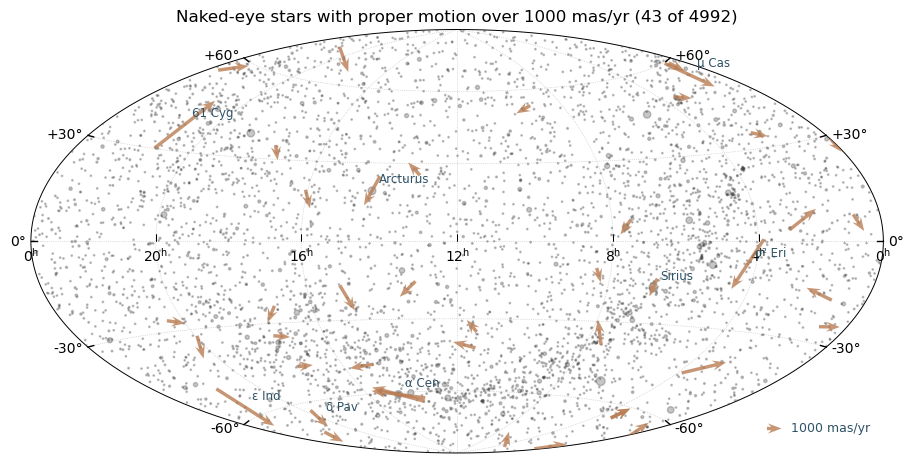

In [3]:
fast = hip[hip_pm > 1000.0]

# The arrow lengths handed to the underlying quiver are (vector magnitude,
# converted to degrees) x scale — so `scale` is the exaggeration factor.
# 5"/yr x 12,000 yr-equivalents ~ 17 degrees for the fastest star here.
SCALE = 20_000

fig, ax = allsky()
pal = annotation_palette()

# Context: every naked-eye star, faintly, sized by brightness.
sph.plot_catalog(ax, hip, ra_col="RAICRS", dec_col="DEICRS",
                 color=pal["stars"], s=np.clip(30 * 10 ** (-0.3 * hip["Vmag"]), 1, 40),
                 alpha=0.3, zorder=2)

# The speedsters: proper-motion arrows, exaggerated to readable length.
res = sph.plot_sky_vectors(ax, fast["RAICRS"], fast["DEICRS"],
                           fast["pmRA"], fast["pmDE"],
                           units="mas", scale=SCALE, width=0.004,
                           color=C[1], zorder=5)

# An exaggeration this large needs a printed key. `sky_quiverkey` draws one in
# physical units — give it the value and its unit, and it reads the scale back
# off the result so the key can't disagree with the arrows it labels.
sph.sky_quiverkey(res, ax, 0.88, 0.06, 1000, "1000 mas/yr", units="mas",
                  labelpos="E", color=C[1], labelcolor=pal["label"],
                  fontproperties={"size": 9})

# Name the famous speedsters.
NAMES = {71683: "α Cen", 5336: "μ Cas", 104214: "61 Cyg", 108870: "ε Ind",
         57939: "Groombridge 1830", 32349: "Sirius", 69673: "Arcturus",
         99240: "δ Pav", 19849: "o² Eri"}
for h, name in NAMES.items():
    row = fast[fast["HIP"] == h]
    if len(row):
        ax.annotate(name, ax.wcs.world_to_pixel_values(row["RAICRS"][0],
                                                       row["DEICRS"][0]),
                    xytext=(5, 6), textcoords="offset points",
                    fontsize=8.5, color=pal["label"], zorder=7)

ax.set_title("Naked-eye stars with proper motion over 1000 mas/yr "
             f"({len(fast)} of {len(hip)})")
fig.canvas.draw()

> **Note:** exaggerated vectors without a printed scale are a figure-referee
> magnet, so always draw the key. Prefer `sph.sky_quiverkey` over matplotlib's
> raw `ax.quiverkey` here: `plot_sky_vectors` measures its arrows in the
> frame's *pixels* internally, so a raw key given a value in degrees comes out
> silently too short — `sky_quiverkey` reads the scale off the result and does
> the conversion for you.

### Auto-scaling and magnitude coloring

Hand-tuning `scale=` gets old. With `scale='auto'`, the helper picks a scale
so the *median* arrow spans `auto_target_deg` degrees — a sensible default for
all-sky views where you just want the field readable. (Curious what it chose,
or want to reuse the same exaggeration on another panel? It comes back as
`res.scale`.) And rather than one
color, `color_by_magnitude=True` colors each arrow by its vector length
(`add_colorbar=True` drops a labeled colorbar alongside; both artists come
back in the result). The colormaps here are sph's own bundled ones —
`lagoon` below, `dusk` and `sunset` elsewhere in this notebook, trimmed to
their saturated body by the small `arrow_cmap` helper up top (the full swatch
tour is in [FITS images & quicklook](fits_images.ipynb)).

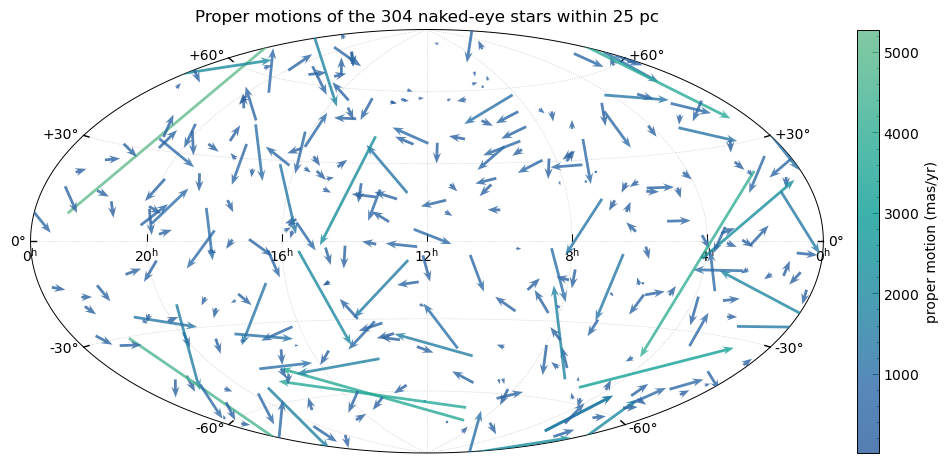

In [4]:
nearby = hip[hip["Plx"] > 40.0]   # closer than 25 pc

fig, ax = allsky()
res = sph.plot_sky_vectors(ax, nearby["RAICRS"], nearby["DEICRS"],
                           nearby["pmRA"], nearby["pmDE"],
                           units="mas", scale="auto", auto_target_deg=7.0,
                           width=0.0035, color_by_magnitude=True,
                           cmap=arrow_cmap("lagoon", hi=0.62), add_colorbar=True,
                           cbar_label="proper motion (mas/yr)")
ax.set_title(f"Proper motions of the {len(nearby)} naked-eye stars within 25 pc")
fig.canvas.draw()

### Styling the arrows

So much for *where* the arrows go — how do they **look**? Every knob below is
an argument to `plot_sky_vectors`, and they divide neatly in two: `scale` sets
how long an arrow is *in degrees on the sky*, while `width` and the three head
parameters set its *shape*, in fractions of the axes. Anything matplotlib's
`quiver` understands (including `path_effects`) passes straight through.

One small field, six panels, one knob each:

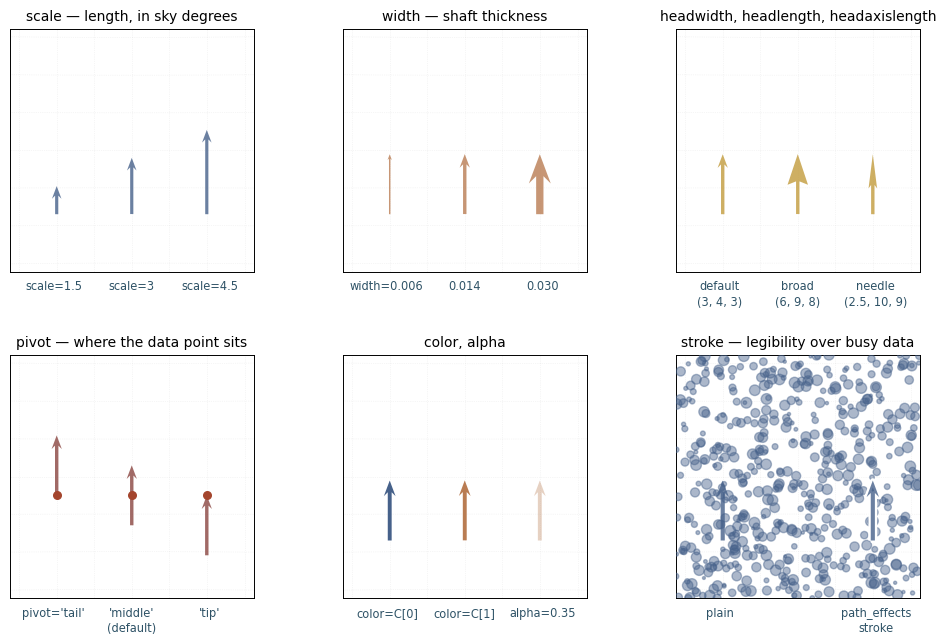

In [5]:
FOV, CEN = 13.0, 180.0
ANCH = np.array([CEN + 4.0, CEN, CEN - 4.0])   # three anchor longitudes
BASE = -3.4                                    # arrows start here, pointing north


def bare_tan(spec, fig):
    """A small, label-free TAN field to demo one knob in."""
    ax = sph.make_wcs_frame(spec, projection="TAN", center_lon=CEN, center_lat=0,
                            fov_deg=FOV, fig=fig, gridalpha=0.15)
    for c in ax.coords:
        c.set_ticklabel_visible(False)
        c.set_ticks_visible(False)
        c.axislabels.set_visible(False)
    return ax


def caption(ax, texts, xs=(0.18, 0.5, 0.82)):
    for x, t in zip(xs, texts):
        ax.text(x, -0.035, t, transform=ax.transAxes, ha="center", va="top",
                fontsize=8.2, color=pal["label"], linespacing=1.35)


pal = annotation_palette()
fig = plt.figure(figsize=(12.5, 7.4))
gs = mpl.gridspec.GridSpec(2, 3, figure=fig, hspace=0.34, wspace=0.10)

# scale — the only knob measured in degrees on the sky
ax = bare_tan(gs[0, 0], fig)
for x, s in zip(ANCH, [1.5, 3.0, 4.5]):
    sph.plot_sky_vectors(ax, [x], [BASE], [0], [1], units="deg", scale=s,
                         color=C[0], width=0.013, pivot="tail")
caption(ax, ["scale=1.5", "scale=3", "scale=4.5"])
ax.set_title("scale — length, in sky degrees", fontsize=10)

# width — shaft thickness, as a fraction of the axes
ax = bare_tan(gs[0, 1], fig)
for x, w in zip(ANCH, [0.006, 0.014, 0.030]):
    sph.plot_sky_vectors(ax, [x], [BASE], [0], [1], units="deg", scale=3.2,
                         color=C[1], width=w, pivot="tail")
caption(ax, ["width=0.006", "0.014", "0.030"])
ax.set_title("width — shaft thickness", fontsize=10)

# the three head parameters, in units of width
ax = bare_tan(gs[0, 2], fig)
heads = [dict(headwidth=3, headlength=4, headaxislength=3),
         dict(headwidth=6, headlength=9, headaxislength=8),
         dict(headwidth=2.5, headlength=10, headaxislength=9)]
for x, h in zip(ANCH, heads):
    sph.plot_sky_vectors(ax, [x], [BASE], [0], [1], units="deg", scale=3.2,
                         color=C[2], width=0.014, pivot="tail", **h)
caption(ax, ["default\n(3, 4, 3)", "broad\n(6, 9, 8)", "needle\n(2.5, 10, 9)"])
ax.set_title("headwidth, headlength, headaxislength", fontsize=10)

# pivot — which part of the arrow lands on the data point (marked)
ax = bare_tan(gs[1, 0], fig)
for x, p in zip(ANCH, ["tail", "middle", "tip"]):
    sph.plot_sky_vectors(ax, [x], [-1.0], [0], [1], units="deg", scale=3.2,
                         color=C[5], width=0.014, pivot=p)
    ax.scatter(x, -1.0, transform=ax.get_transform("world"), s=30,
               color=pal["accent"], zorder=8)
caption(ax, ["pivot='tail'", "'middle'\n(default)", "'tip'"])
ax.set_title("pivot — where the data point sits", fontsize=10)

# color and alpha
ax = bare_tan(gs[1, 1], fig)
for x, col, a in zip(ANCH, [C[0], C[1], C[1]], [1.0, 1.0, 0.35]):
    sph.plot_sky_vectors(ax, [x], [BASE], [0], [1], units="deg", scale=3.2,
                         color=col, alpha=a, width=0.016, pivot="tail")
caption(ax, ["color=C[0]", "color=C[1]", "alpha=0.35"])
ax.set_title("color, alpha", fontsize=10)

# stroke — anything quiver takes passes through, path_effects included
ax = bare_tan(gs[1, 2], fig)
rng = np.random.default_rng(7)
# Clutter in the arrows' own color: the hard case a stroke is made for.
ax.scatter(rng.uniform(CEN - 6.5, CEN + 6.5, 550), rng.uniform(-6.5, 6.5, 550),
           transform=ax.get_transform("world"), s=rng.uniform(4, 60, 550),
           color=C[0], alpha=0.45, zorder=1)
for x, extra in zip(ANCH[[0, 2]],
                    [{}, dict(path_effects=[pe.withStroke(
                        linewidth=3.4, foreground=pal["fig_bg"])])]):
    sph.plot_sky_vectors(ax, [x], [BASE], [0], [1], units="deg", scale=3.2,
                         color=C[0], width=0.017, pivot="tail", zorder=5, **extra)
caption(ax, ["plain", "", "path_effects\nstroke"])
ax.set_title("stroke — legibility over busy data", fontsize=10)
fig.canvas.draw()

| Knob | Units | What it controls |
|---|---|---|
| `scale` | sky degrees per unit of vector magnitude | arrow **length** (`'auto'` + `auto_target_deg` sizes it for you) |
| `units` | — | how `dlon`/`dlat` are read: `'deg'`, `'arcmin'`, `'arcsec'`, `'mas'`, `'uas'` |
| `width` | fraction of the axes | shaft thickness |
| `headwidth`, `headlength`, `headaxislength` | multiples of `width` | head shape — broad and blunt, or long and needle-like |
| `pivot` | — | which part of the arrow lands on the data point: `'tail'`, `'middle'` (default), `'tip'` |
| `color`, `alpha`, `zorder` | — | the usual matplotlib styling (`color` also takes a per-source array) |
| `**kwargs` | — | forwarded to `quiver` — `path_effects`, `linewidth`, `edgecolor`, … |

> **Note:** `scale` is the one measurement in *sky* degrees; `width` and the
> head parameters are fractions of the **axes**. So a figure resized after the
> fact keeps its arrow lengths but rescales its arrowheads.

One last argument is about your *data*, not its appearance. **`cos_dec=`** is a
convention flag: tabulated proper motions are almost always μ<sub>α</sub>cosδ
(already cosδ-scaled), which is the default `cos_dec=True`. If you feed raw
coordinate differences `ra2 - ra1` instead, set `cos_dec=False` and the
correction is applied for you.

## 3. Displacement arrows

`plot_sky_vectors` draws a *field* — one styling, many arrows, lengths set by
a common scale. Its per-source sibling `plot_displacement()` instead connects
**two epochs of actual positions** with individual arrows whose shafts follow
the great-circle path between them (`geodesic=True`, seam-aware). Reach for it
when you have few sources, genuinely large displacements, or want each arrow
styled on its own.

Nothing on the sky obliges us to wait: with real proper motions we can *fast
forward*. Here is what 100,000 years does to the Big Dipper.

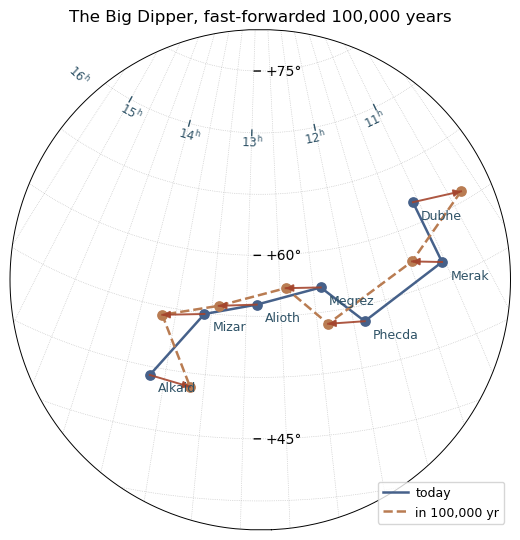

In [6]:
DIPPER = {54061: "Dubhe", 53910: "Merak", 58001: "Phecda", 59774: "Megrez",
          62956: "Alioth", 65378: "Mizar", 67301: "Alkaid"}
dip = hip[np.isin(hip["HIP"], list(DIPPER))]
# Keep the asterism drawing order (bowl to handle), not table order:
order = [np.where(dip["HIP"] == h)[0][0] for h in
         [54061, 53910, 58001, 59774, 62956, 65378, 67301]]
dip = dip[order]

dt_yr = 100_000
ra1, de1 = np.array(dip["RAICRS"]), np.array(dip["DEICRS"])
# Linear propagation: fine for a demo (see the note below).
ra2 = ra1 + dip["pmRA"] / np.cos(np.radians(de1)) * dt_yr / 3.6e6
de2 = de1 + dip["pmDE"] * dt_yr / 3.6e6

fig = plt.figure(figsize=(9, 6.5))
ax = sph.make_wcs_frame(111, projection="STG", center_lon=193, center_lat=58,
                        fov_deg=42, fig=fig)
pal = annotation_palette()

# The asterism, then and now:
for r, d, color, ls, lbl in [(ra1, de1, C[0], "-", "today"),
                             (ra2, de2, C[1], "--", "in 100,000 yr")]:
    ax.plot(r, d, transform=ax.get_transform("world"), color=color,
            ls=ls, lw=1.8, zorder=4, label=lbl)
    ax.scatter(r, d, transform=ax.get_transform("world"), s=45, color=color,
               zorder=5)

sph.plot_displacement(ax, ra1, de1, ra2, de2, color=pal["accent"],
                      lw=1.4, alpha=0.9, arrowstyle="-|>", zorder=6)

for r, d, name in zip(ra1, de1, [DIPPER[h] for h in dip["HIP"]]):
    ax.annotate(name, ax.wcs.world_to_pixel_values(r, d),
                xytext=(6, -12), textcoords="offset points",
                fontsize=9, color=pal["label"], zorder=7)

# The frame's own RA labels would sit right among the stars. `add_curved_lon_ticks`
# re-hangs them along a parallel of our choosing — here +70°, up out of the way.
# Passing an explicit `lon_ticks` list (rather than `lon_spacing`) keeps every
# label inside the frame; meridians outside the field would otherwise be labeled
# off-canvas.
sph.add_curved_lon_ticks(ax, tick_lat=70, lon_ticks=np.arange(165, 241, 15),
                         color=pal["label"], fontsize=8.5)

ax.legend(loc="lower right", fontsize=9)
ax.set_title("The Big Dipper, fast-forwarded 100,000 years")
fig.canvas.draw()

Alkaid and Dubhe, at the ends, famously move *against* the five middle stars —
those five are a genuine co-moving group (the Ursa Major moving group), while
the ends are unrelated interlopers, and the asterism shears apart accordingly.

> **Note:** we propagated positions linearly (`ra + μ·Δt`). Over 10⁵ years
> that's a demo-grade approximation — real long-horizon propagation is a great
> circle on the sphere and needs radial velocity too (stars approach and
> recede, changing μ itself). For rigorous work use
> `astropy.coordinates.SkyCoord.apply_space_motion()`.

## 4. Vector spherical harmonics

Individual arrows tell individual stories; the *systematic* patterns hiding in
a vector field have a standard language of their own. **Vector spherical
harmonics (VSH)** decompose any smooth vector field on the sphere into modes,
exactly as ordinary spherical harmonics decompose a scalar map — and the
lowest-degree modes are the ones with famous physical meanings. This is the
working vocabulary of reference-frame comparisons (ICRF vs Gaia, catalog vs
catalog): report the rotation between two frames, the glide, and whatever ℓ=2
structure remains.

skyplothelper's VSH tools are **forward-model only**: give `vsh_field()` a
parameter set and positions, and it evaluates the field there. The 16
parameters of the ℓ ≤ 2 model, in `VSH_PARAM_NAMES` order:

| Family | Parameters | Pattern on the sky | Where you meet it |
|---|---|---|---|
| **Rotation** (toroidal ℓ=1) | `R_1`, `R_2`, `R_3` | rigid spin about the x / y / z axis — flow along circles around that axis | frame-orientation offsets; residual spin between catalogs |
| **Glide** (spheroidal ℓ=1) | `D_1`, `D_2`, `D_3` | dipole flow — away from one point, converging on the opposite point | Galactic aberration; solar-motion reflex (§6) |
| **Quadrupole, electric** (spheroidal ℓ=2) | `E_20`, `E_21_Re/Im`, `E_22_Re/Im` | divergence-type ℓ=2 flow (sources and sinks in quadrants) | zonal/systematic distortions between catalogs |
| **Quadrupole, magnetic** (toroidal ℓ=2) | `M_20`, `M_21_Re/Im`, `M_22_Re/Im` | curl-type ℓ=2 flow (swirls in quadrants) | same, curl-like part |

> **Note:** the parameter convention here — names, ordering, and
> normalization — follows the ICRF3 analysis (Charlot et al. 2020), which
> builds on the VSH formalism of Mignard & Klioner (2012) and its application
> to VLBI astrometry by Titov & Lambert (2013). Full citations in
> [Data and references](#Data-and-references).

Parameters go in as a dict (anything omitted is zero) or a bare 16-element
sequence in `VSH_PARAM_NAMES` order — the dict form sidesteps the ordering
pitfall. Here is one representative of each family — on the left flattened onto
an all-sky map, on the right wrapped back onto the sphere it actually lives on.
A globe hides half the sky, so we keep only the near-side points, which is
exactly what `orthographic_visibility` reports. And because `scale` is measured
in sky degrees, the *same* number gives arrows of the same angular length in
both projections — the pair is directly comparable.

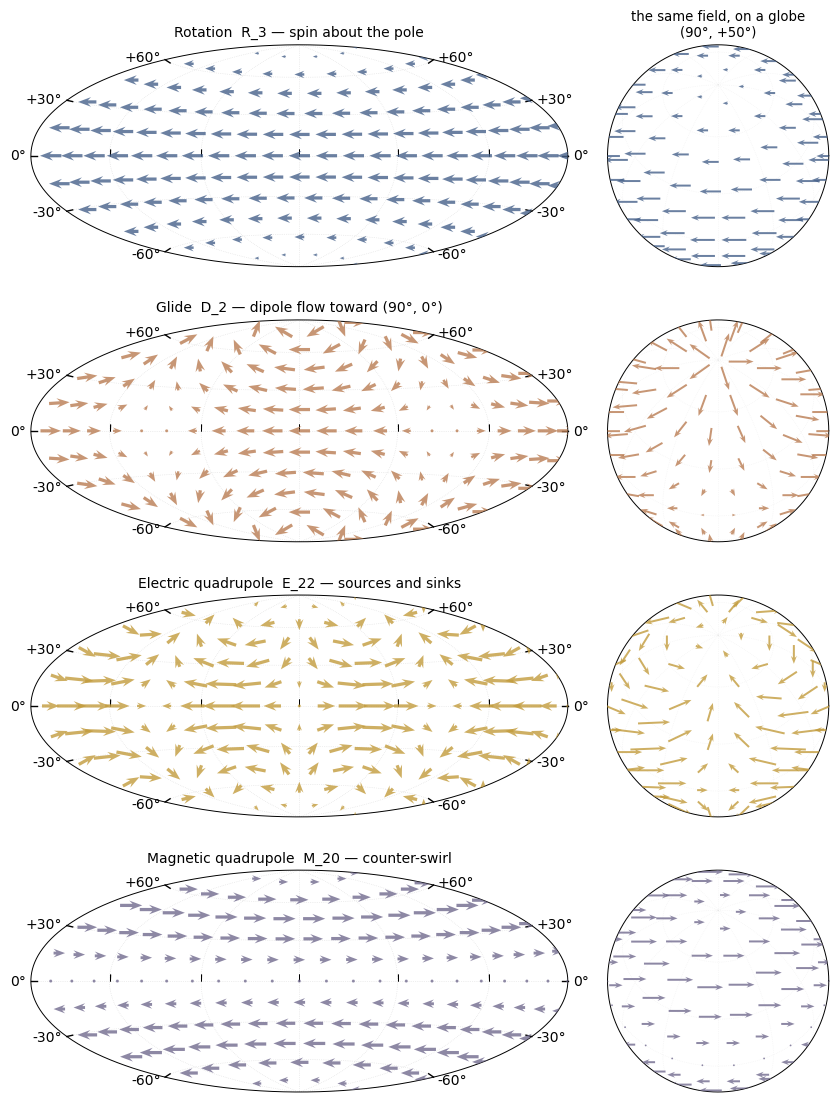

In [7]:
glon, glat = sphere_grid()
G_LON0, G_LAT0 = 90.0, 50.0        # the globe's viewpoint
TARGET_DEG = 11.0                  # median arrow length, both columns

MODES = [({"R_3": 1.0}, "Rotation  R_3 — spin about the pole", C[0]),
         ({"D_2": 1.0}, "Glide  D_2 — dipole flow toward (90°, 0°)", C[1]),
         ({"E_22_Re": 1.0}, "Electric quadrupole  E_22 — sources and sinks", C[2]),
         ({"M_20": 1.0}, "Magnetic quadrupole  M_20 — counter-swirl", C[6])]

fig = plt.figure(figsize=(10.6, 13.6))
gs = mpl.gridspec.GridSpec(4, 2, figure=fig, width_ratios=[2, 1],
                           hspace=0.24, wspace=0.04)
front = sph.orthographic_visibility(glon, glat, G_LON0, G_LAT0)

for i, (params, title, color) in enumerate(MODES):
    dlon, dlat = sph.vsh_field(glon, glat, params)
    mag = np.hypot(dlon, dlat)
    scale = TARGET_DEG / np.median(mag[mag > 0])   # one scale, shared by the pair

    ax = sph.make_wcs_frame(gs[i, 0], projection="AIT", center=180, fig=fig,
                            gridalpha=0.25)
    sph.plot_sky_vectors(ax, glon, glat, dlon, dlat, units="deg", scale=scale,
                         width=0.006, color=color)
    ax.coords[0].set_ticklabel_visible(False)
    ax.set_title(title, fontsize=10)

    # make_globe_frame has no `fig=`, so point pyplot at ours first.
    plt.figure(fig.number)
    axg = sph.make_globe_frame(gs[i, 1], center_LONdeg=G_LON0,
                               center_LATdeg=G_LAT0, gridalpha=0.25,
                               tick_style="native")
    for c in axg.coords:                 # a reference globe needs no labels
        c.set_ticklabel_visible(False)
        c.set_ticks_visible(False)
    sph.plot_sky_vectors(axg, glon[front], glat[front], dlon[front], dlat[front],
                         units="deg", scale=scale, width=0.009, color=color)
    if i == 0:
        axg.set_title(f"the same field, on a globe\n({G_LON0:.0f}°, +{G_LAT0:.0f}°)",
                      fontsize=9.5)
fig.canvas.draw()

The globe column provides the spherical view. Rotation flows *along* circles of latitude,
wrapping the pole; glide converges on one point of its axis and diverges from
the antipode — on the sphere that reads instantly, while the flat map smears
both points across the whole top and bottom edges. The two ℓ=2 families repeat
the same distinction one degree up: electric modes diverge, magnetic modes
swirl.

> **Tip:** the globe is a `make_globe_frame` (orthographic) axes, so far-side
> points project to NaN. Filter them yourself with `orthographic_visibility`
> before plotting, as above — that keeps the arrow count honest and stops
> matplotlib from quietly dropping vectors.

### Applying a VSH distortion

Two companions turn a parameter set into *displaced positions* rather than a
field: `vsh_shift_sources()` shifts your own source list, and
`vsh_shift_frame()` builds and shifts a reference graticule of points — both
with a `scale=` exaggeration so a μas-level effect can be made visible. With
`plot_displacement` from §3, that's a before/after picture of what a VSH
model *does* to the sky:

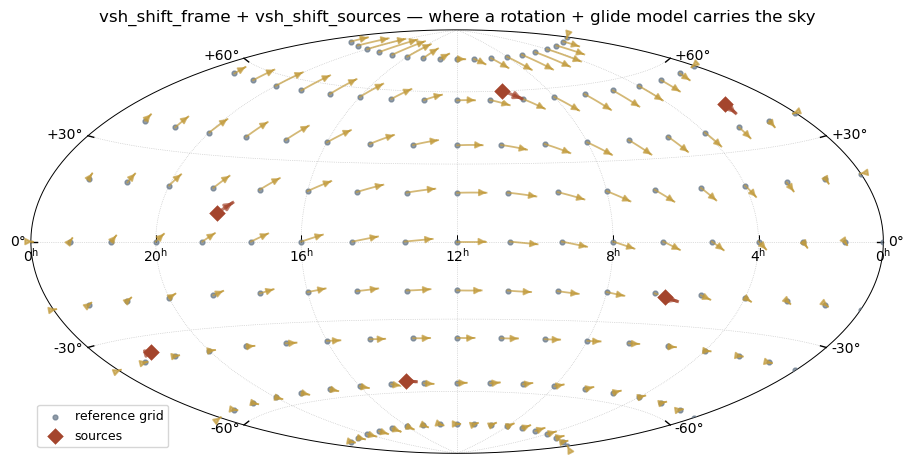

In [8]:
params = {"R_1": 3.0, "R_3": 6.0, "D_2": 5.0}   # rotation + glide combo (deg)

# The reference graticule, before and after:
lon0, lat0, lon1, lat1 = sph.vsh_shift_frame(params, n_lon=18, n_lat=9,
                                             lat_max=75, scale=1.0)

# ...and the same distortion applied to a handful of *sources* of our own:
src_lon = np.array([30.0, 95.0, 150.0, 210.0, 275.0, 330.0])
src_lat = np.array([45.0, -20.0, 60.0, -55.0, 10.0, -35.0])
src_lon1, src_lat1 = sph.vsh_shift_sources(src_lon, src_lat, params, scale=1.0)

fig, ax = allsky()
pal = annotation_palette()
ax.scatter(lon0, lat0, transform=ax.get_transform("world"),
           s=12, color=pal["compass"], alpha=0.75, zorder=4, label="reference grid")
sph.plot_displacement(ax, lon0, lat0, lon1, lat1,
                      color=C[2], lw=1.3, arrowstyle="-|>", zorder=5)
ax.scatter(src_lon, src_lat, transform=ax.get_transform("world"),
           s=85, marker="D", color=pal["accent"], edgecolor=pal["fig_bg"],
           linewidth=0.8, zorder=6, label="sources")
sph.plot_displacement(ax, src_lon, src_lat, src_lon1, src_lat1,
                      color=pal["accent"], lw=2.2, arrowstyle="-|>", zorder=6)
ax.legend(loc="lower left", fontsize=9)
ax.set_title("vsh_shift_frame + vsh_shift_sources — where a rotation + glide "
             "model carries the sky")
fig.canvas.draw()

## 5. Fitting a VSH model

This package deliberately stops at the forward model — but the inverse problem
is *linear*, so recovering VSH parameters from measured vectors is a few lines
of numpy you can do yourself. Build the design matrix by evaluating `vsh_field`
once per unit parameter, and least-squares does the rest.

To trust a fit, first watch it recover a *known* answer. We inject a chosen
rotation + glide into a synthetic catalog, add per-source noise as large as
the biggest parameter, and fit:

In [9]:
rng = np.random.default_rng(42)
n_src = 600

# Synthetic quasar catalog, roughly uniform on the sphere:
s_lon = rng.uniform(0, 360, n_src)
s_lat = np.degrees(np.arcsin(rng.uniform(-0.97, 0.97, n_src)))

# The injected truth (mas) — and per-source noise as large as its biggest term:
TRUTH = {"R_1": -3.0, "R_2": 5.0, "R_3": 2.0, "D_1": 4.0, "D_2": -2.0, "D_3": 6.0}
dlon_true, dlat_true = sph.vsh_field(s_lon, s_lat, TRUTH)
noise = 6.0
dlon_obs = dlon_true + rng.normal(0, noise, n_src)
dlat_obs = dlat_true + rng.normal(0, noise, n_src)

# Design matrix: column j = the field of parameter j at unit amplitude.
FIT_PARAMS = ["R_1", "R_2", "R_3", "D_1", "D_2", "D_3"]
A = np.zeros((2 * n_src, len(FIT_PARAMS)))
for j, name in enumerate(FIT_PARAMS):
    ulon, ulat = sph.vsh_field(s_lon, s_lat, {name: 1.0})
    A[:, j] = np.concatenate([ulon, ulat])

fit, *_ = np.linalg.lstsq(A, np.concatenate([dlon_obs, dlat_obs]), rcond=None)

print(f"{'param':>6}  {'true':>6}  {'fitted':>8}")
for name, value in zip(FIT_PARAMS, fit):
    print(f"{name:>6}  {TRUTH[name]:>6.1f}  {value:>8.2f}")

 param    true    fitted
   R_1    -3.0     -2.86
   R_2     5.0      4.54
   R_3     2.0      2.59
   D_1     4.0      3.64
   D_2    -2.0     -2.40
   D_3     6.0      5.78


Every parameter is recovered to within about half a degree — despite
per-source noise as large as the signal — showing the power of fitting a
global pattern to many sources at once. The matching picture is the
geodesist's standard triptych: the data, the fitted model, and what's left
when you subtract it.

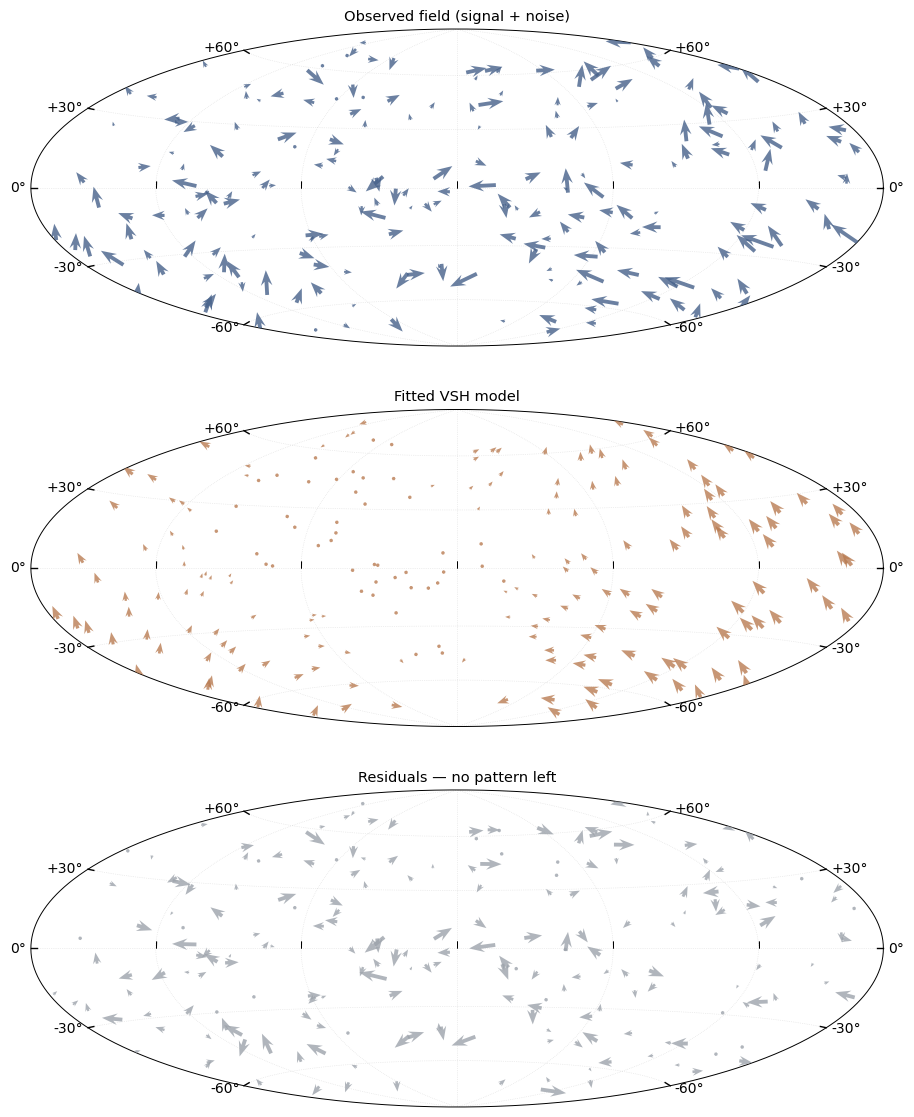

In [10]:
fig = plt.figure(figsize=(11, 14))
panels = [(dlon_obs, dlat_obs, "Observed field (signal + noise)", C[0]),
          (A @ fit, None, "Fitted VSH model", C[1]),
          (dlon_obs - (A @ fit)[:n_src], dlat_obs - (A @ fit)[n_src:],
           "Residuals — no pattern left", C[3])]

# One shared scale across the three panels so lengths stay comparable.
tri_scale = 0.6
show = slice(None, None, 3)   # thin to every 3rd source so arrows read clearly
for i, (dl, db, title, color) in enumerate(panels):
    if db is None:                       # unpack the stacked model vector
        dl, db = dl[:n_src], dl[n_src:]
    fig, ax = allsky(311 + i, fig=fig, gridalpha=0.25)
    sph.plot_sky_vectors(ax, s_lon[show], s_lat[show], dl[show], db[show],
                         units="deg", scale=tri_scale, width=0.0045,
                         color=color)
    ax.set_title(title, fontsize=10.5)
    ax.coords[0].set_ticklabel_visible(False)
fig.canvas.draw()

> **Note:** the fit above is *user code*, deliberately — sph gives you the
> forward model (`vsh_field`) and the plotting; the statistics are yours to
> own (weights, outlier rejection, the ℓ=2 terms, error bars). Extending the
> design matrix to all 16 parameters is the same loop over
> `sph.VSH_PARAM_NAMES`.

## 6. The solar apex from naked-eye stars

Time to put the kinematics half together on real data. The Sun is moving
with respect to the nearby stars — toward a point in Hercules called the
**solar apex** — so the nearby stars, on average, appear to stream the other
way, toward the antapex. That reflex is a *glide* in the proper motions,
exactly the dipole pattern of §1, hiding under each star's own peculiar
motion.

Individually the naked-eye stars scatter every which way (we saw as much in
§2). But bin them into sky cells and take the **median** proper motion per
cell, and the coherent flow surfaces:

In [11]:
near = hip[hip["Plx"] > 10.0]        # within 100 pc: 2272 stars
ra_n, de_n = np.array(near["RAICRS"]), np.array(near["DEICRS"])
pm_ra, pm_de = np.array(near["pmRA"]), np.array(near["pmDE"])

# Median proper motion in 30-degree sky cells (only cells with >= 12 stars):
cell_lon, cell_lat, cell_pmra, cell_pmde = [], [], [], []
for lo in np.arange(0, 360, 30):
    for la in np.arange(-90, 90, 30):
        sel = ((ra_n >= lo) & (ra_n < lo + 30)
               & (de_n >= la) & (de_n < la + 30))
        if sel.sum() >= 12:
            cell_lon.append(lo + 15)
            cell_lat.append(la + 15)
            cell_pmra.append(np.median(pm_ra[sel]))
            cell_pmde.append(np.median(pm_de[sel]))
print(f"{len(cell_lon)} cells with enough stars")

64 cells with enough stars


And now the §5 fit, verbatim, on the real per-star proper motions — same
six-parameter design matrix, real sky this time. The fitted glide vector
points at the convergence of the flow (the antapex); flip it and we have
*measured the direction of the Sun's motion* from nothing but bright-star
astrometry:

In [12]:
A = np.zeros((2 * len(near), len(FIT_PARAMS)))
for j, name in enumerate(FIT_PARAMS):
    ulon, ulat = sph.vsh_field(ra_n, de_n, {name: 1.0})
    A[:, j] = np.concatenate([ulon, ulat])
fit_real, *_ = np.linalg.lstsq(A, np.concatenate([pm_ra, pm_de]), rcond=None)

D = fit_real[3:]                     # the glide part, (D_1, D_2, D_3) in mas/yr
antapex = D / np.linalg.norm(D)      # flow converges toward +D
apex_ra = np.degrees(np.arctan2(-antapex[1], -antapex[0])) % 360
apex_dec = np.degrees(np.arcsin(-antapex[2]))
print(f"glide amplitude |D| = {np.linalg.norm(D):.1f} mas/yr")
print(f"fitted solar apex:  RA = {apex_ra:6.1f} deg   Dec = {apex_dec:+5.1f} deg")
print("classical solar apex: RA ~ 271 deg   Dec ~ +30 deg  (18h, Hercules)")

glide amplitude |D| = 114.0 mas/yr
fitted solar apex:  RA =  269.9 deg   Dec = +25.8 deg
classical solar apex: RA ~ 271 deg   Dec ~ +30 deg  (18h, Hercules)


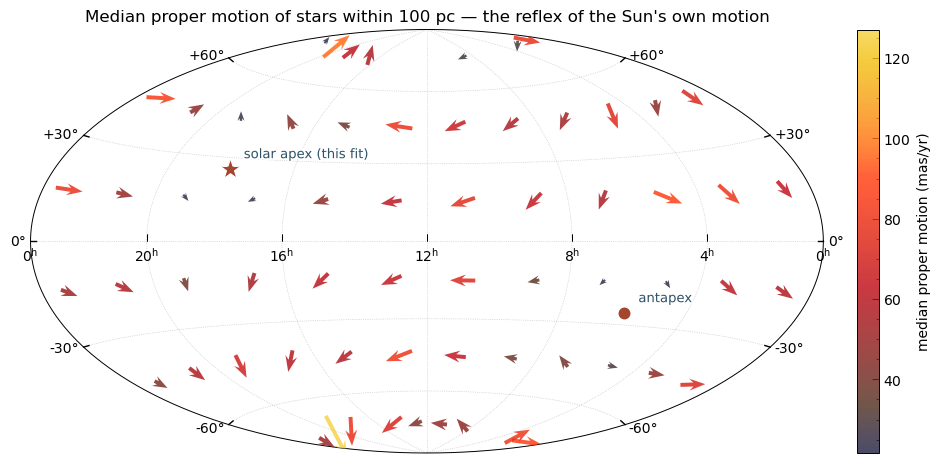

In [13]:
fig, ax = allsky()
pal = annotation_palette()

res = sph.plot_sky_vectors(ax, cell_lon, cell_lat, cell_pmra, cell_pmde,
                           units="mas", scale="auto", auto_target_deg=8.0,
                           width=0.005, color_by_magnitude=True,
                           cmap=arrow_cmap("sunset"), add_colorbar=True,
                           cbar_label="median proper motion (mas/yr)")

for r, d, marker, label in [(apex_ra, apex_dec, "*", "solar apex (this fit)"),
                            ((apex_ra + 180) % 360, -apex_dec, "o", "antapex")]:
    ax.scatter(r, d, transform=ax.get_transform("world"), marker=marker,
               s=260 if marker == "*" else 90, color=pal["accent"],
               edgecolor=pal["fig_bg"], linewidth=0.9, zorder=6)
    ax.annotate(label, ax.wcs.world_to_pixel_values(r, d), xytext=(10, 8),
                textcoords="offset points", fontsize=9.5, color=pal["label"],
                path_effects=[pe.withStroke(linewidth=2.5,
                                            foreground=pal["fig_bg"])],
                zorder=7)

ax.set_title("Median proper motion of stars within 100 pc — the reflex of "
             "the Sun's own motion")
fig.canvas.draw()

The binned field converges on the antapex and drains away from the apex —
the same dipole geometry as §1's aberration figure, four orders of magnitude
stronger, and recovered here from a 4-column CSV of naked-eye stars. (The
apex has been charted since William Herschel's day; for the modern solar
motion with respect to the local standard of rest, see Schönrich, Binney &
Dehnen 2010.)

> **Note:** treat the numbers as a demonstration, not a measurement. Bright
> stars are a kinematically biased sample (young, disk-concentrated), the
> sample shares the Galaxy's differential rotation (that's partly what the
> rotation terms in the fit absorb), and we fit plain unweighted least
> squares. That the apex still lands in the right corner of Hercules is a
> testament to how strong the reflex signal is.

## 7. The co-visible sky

From motion *on* the sky to geometry *of* the sky: when several ground
stations observe together — a VLBI network, a follow-up campaign across
observatories — the first question is purely geometric. **Which sky can all
of them see at once?**

Each station sees a spherical cap: everything above its elevation limit,
centered on its zenith. sph answers the network question with three helpers,
each returning something you can both *draw* and *query*:

- `covisibility_circles()` — each station's cap at a given time, as circle
  specs (center + radius);
- `covisibility_region()` — the instantaneous intersection, as a
  [compound region](regions.ipynb);
- `covisibility_duration_band()` — the declination band visible for at least
  `min_hours=` per day: the long-exposure version of the same question.

Stations go in as a dict of `{"name": {"lat": ..., "lon": ...}}` (degrees),
time as anything `astropy.time.Time` accepts. We'll use a fixed instant so
the notebook is reproducible:

In [14]:
TIME = "2026-07-02T07:00:00"

STATIONS = {"Kokee":      {"lat": 22.13,  "lon": -159.665},
            "Wettzell":   {"lat": 49.145, "lon": 12.878},
            "GBT":        {"lat": 38.43,  "lon": -79.84},
            "VLA":        {"lat": 34.08,  "lon": -107.62}}

### One station, one cap

Start with a single antenna. The cap's size is set by `el_min=` — the
elevation limit below which the telescope can't observe. Raising (further restricting) the minimum elevation shrinks the
usable sky dramatically:

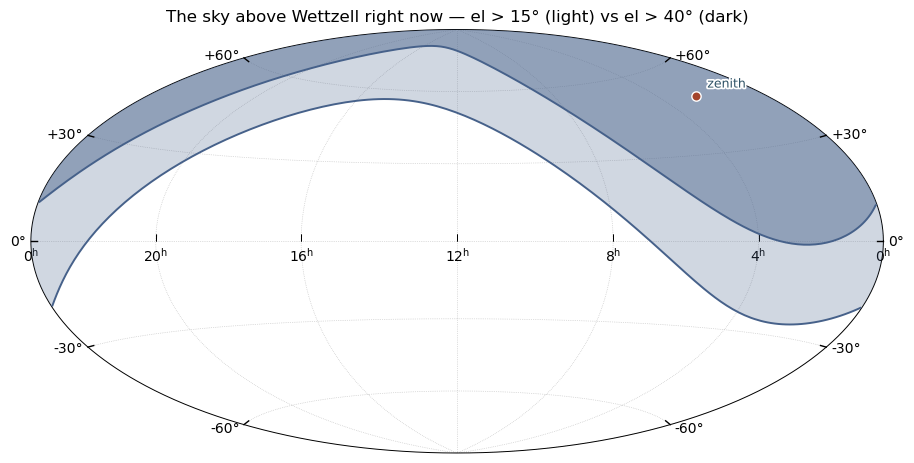

In [15]:
fig, ax = allsky()
pal = annotation_palette()
wett = {"Wettzell": STATIONS["Wettzell"]}

for el, color, alpha in [(15, C[0], 0.25), (40, C[0], 0.45)]:
    reg = sph.covisibility_region(ax, wett, TIME, el_min=el)
    reg.render(facecolor=color, alpha=alpha, edgecolor=color, lw=1.4)

# The zenith point — covisibility_circles hands back each cap's center:
cap = sph.covisibility_circles(wett, TIME, el_min=15)[0]
ax.scatter(cap["center"].ra.deg, cap["center"].dec.deg,
           transform=ax.get_transform("world"), s=45, color=pal["accent"],
           edgecolor=pal["fig_bg"], zorder=6)
ax.annotate("zenith", ax.wcs.world_to_pixel_values(cap["center"].ra.deg,
                                                   cap["center"].dec.deg),
            xytext=(8, 6), textcoords="offset points", fontsize=9,
            color=pal["label"],
            path_effects=[pe.withStroke(linewidth=2.5, foreground=pal["fig_bg"])])
ax.set_title("The sky above Wettzell right now — el > 15° (light) vs el > 40° (dark)")
fig.canvas.draw()

### Two stations — the intersection

Add a second station and intersect. Kokee (Hawaii) and Wettzell (Bavaria) are
a canonical geodetic pair nearly half the Earth apart — their mutual sky is a
thin lens, and *that* is where they can measure together:

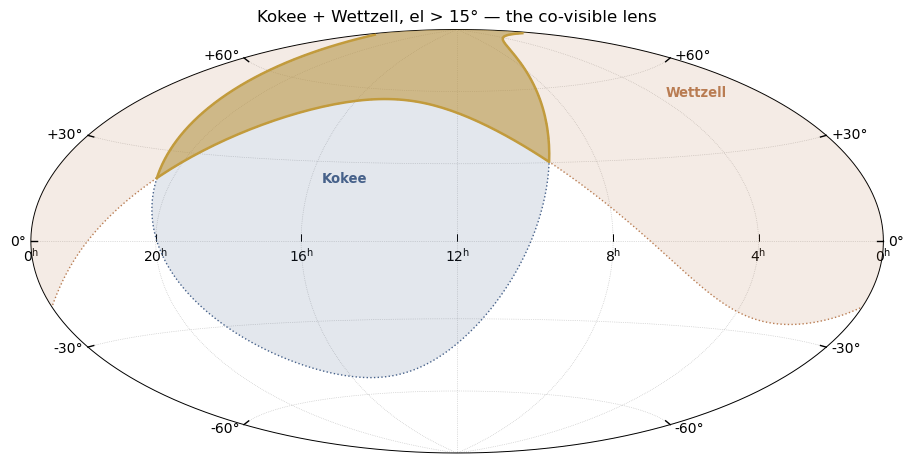

In [16]:
pair = {k: STATIONS[k] for k in ("Kokee", "Wettzell")}

fig, ax = allsky()
pal = annotation_palette()

# Each station's own cap, faintly, so the intersection reads as their overlap:
for (name, st), color in zip(pair.items(), (C[0], C[1])):
    reg = sph.covisibility_region(ax, {name: st}, TIME, el_min=15)
    reg.render(facecolor=color, alpha=0.15, edgecolor=color, lw=1.0,
               linestyle=":")
    cap = sph.covisibility_circles({name: st}, TIME, el_min=15)[0]
    ax.annotate(name, ax.wcs.world_to_pixel_values(cap["center"].ra.deg,
                                                   cap["center"].dec.deg),
                ha="center", fontsize=9.5, color=color, fontweight="bold")

# The co-visible sky:
both = sph.covisibility_region(ax, pair, TIME, el_min=15)
both.render(facecolor=C[2], alpha=0.5, edgecolor=C[2], lw=1.8)
ax.set_title("Kokee + Wettzell, el > 15° — the co-visible lens")
fig.canvas.draw()

### Real horizons — the azimuth mask

Real sites aren't ideal: a mountain, a tree line, a neighboring dish blocks
part of the local horizon. Give a station a `hor_mask` —
`[[azimuths], [elevations]]`, the minimum usable elevation as a function of
compass azimuth — and `covisibility_region` clips its cap to that horizon
instead of a clean circle.

The VLBA antenna on **Mauna Kea** is a natural example: the volcano's summit
cone rises above the pad to the north, cutting the northern sky. The mask
below is a *representative* stand-in — peaking near 15° in the north, a clean
~8° elsewhere; the real per-station profiles ship with the VLBA scheduling
software — but the geometry it shows is honest: a northern obstruction eats
into the *high-declination* sky, exactly where a mid-northern station's cap
reaches up over the pole.

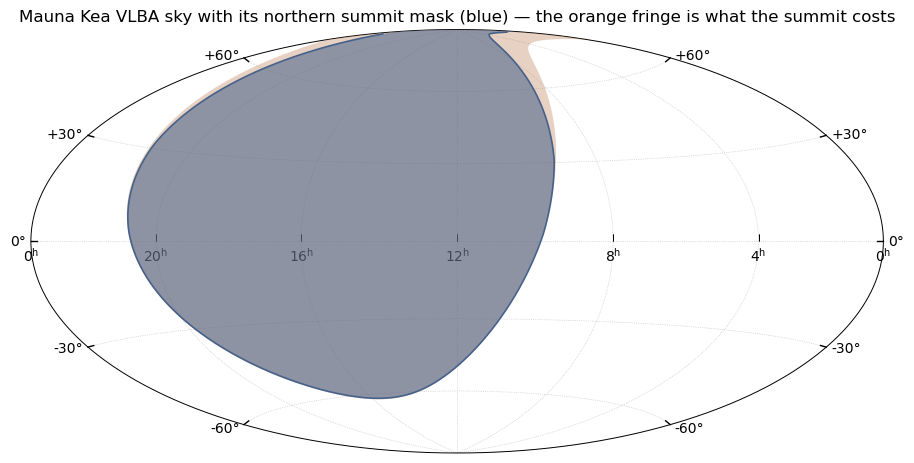

In [17]:
mk = {"lat": 19.80, "lon": -155.46}          # VLBA Mauna Kea
masked_mk = dict(mk)
# Summit cone to the north (az 0): the horizon rises to ~15°, tapering to a
# clean ~8° around the rest of the compass.
masked_mk["hor_mask"] = [[0, 30, 60, 90, 180, 270, 300, 330],
                         [15, 12, 9, 8, 8, 8, 9, 12]]

fig, ax = allsky()
ideal = sph.covisibility_region(ax, {"MK": mk}, TIME, el_min=8)
ideal.render(facecolor=C[1], alpha=0.35, edgecolor="none")
real = sph.covisibility_region(ax, {"MK": masked_mk}, TIME, el_min=8)
real.render(facecolor=C[0], alpha=0.55, edgecolor=C[0], lw=1.2)
ax.set_title("Mauna Kea VLBA sky with its northern summit mask (blue) — "
             "the orange fringe is what the summit costs")
fig.canvas.draw()

### k of N — when "all stations" is too strict

How many stations do you actually need? For imaging VLBI the naive
answer is *all of them* — every antenna on-source maximizes uv-coverage — and
that is what the strict intersection above describes. Geodetic and monitoring
programs, though, routinely observe in subarrays, where the real constraint is
"at least k stations up." Pass `min_stations=` and the region relaxes to
exactly that — the k = 3 sky wraps generously around the strict all-4 core:

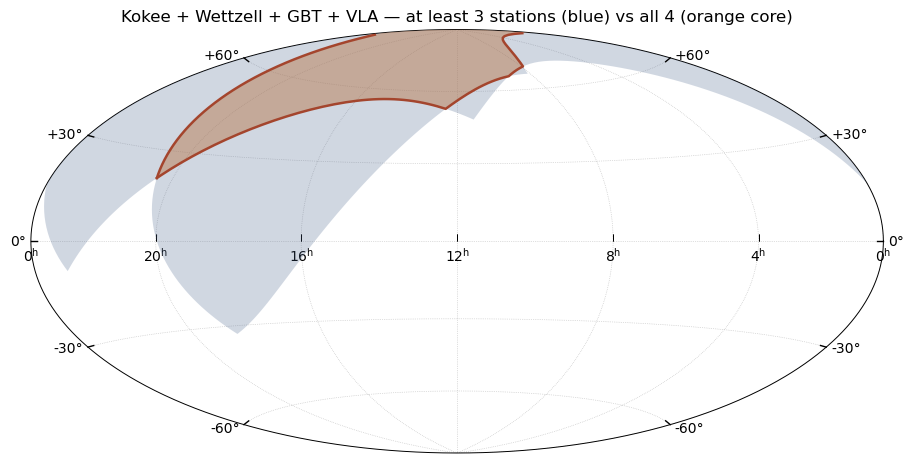

In [18]:
fig, ax = allsky()
pal = annotation_palette()

at_least_3 = sph.covisibility_region(ax, STATIONS, TIME, el_min=15,
                                     min_stations=3)
at_least_3.render(facecolor=C[0], alpha=0.25, edgecolor="none")
all_4 = sph.covisibility_region(ax, STATIONS, TIME, el_min=15)
all_4.render(facecolor=C[1], alpha=0.5, edgecolor=pal["accent"], lw=1.8)

ax.set_title("Kokee + Wettzell + GBT + VLA — at least 3 stations (blue) "
             "vs all 4 (orange core)")
fig.canvas.draw()

### The long exposure — duration bands

An instantaneous region answers "now"; scheduling wants "on a typical day."
As the Earth turns, each cap sweeps a band of declinations, and
`covisibility_duration_band()` returns the declinations that stay co-visible
for at least `min_hours=` per day. For a globe-spanning array no sky is ever
visible to all six at once — but the k-of-N bands tell you exactly what a
4-hour observation can reach:

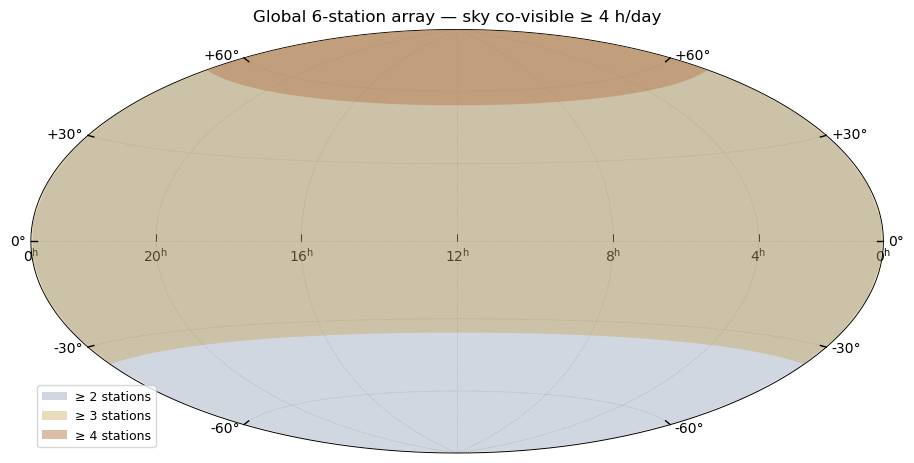

In [19]:
ARRAY = {"VLA":            {"lat": 34.1,  "lon": -107.6},
         "Effelsberg":     {"lat": 50.5,  "lon": 6.9},
         "ATCA":           {"lat": -30.3, "lon": 149.6},
         "Hartebeesthoek": {"lat": -25.9, "lon": 27.7},
         "Kokee":          {"lat": 22.1,  "lon": -159.7},
         "Sheshan":        {"lat": 31.1,  "lon": 121.2}}

fig, ax = allsky()
for k, color, alpha in [(2, C[0], 0.25), (3, C[2], 0.35), (4, C[1], 0.5)]:
    band = sph.covisibility_duration_band(ax, ARRAY, min_hours=4.0,
                                          el_min=15, min_stations=k)
    if not band.is_empty:
        band.render(facecolor=color, alpha=alpha, edgecolor="none",
                    label=f"≥ {k} stations")
ax.legend(loc="lower left", fontsize=9)
ax.set_title("Global 6-station array — sky co-visible ≥ 4 h/day")
fig.canvas.draw()

All three helpers return [compound regions](regions.ipynb), so everything
from that tutorial applies: set algebra, `.contains_points()` membership
tests, rendering on either backend. §8 puts the membership test to work.

> **Important:** co-visibility is *geometry above an elevation limit* — not an
> observability calculation. No Sun avoidance, no slew limits, no weather.
> For real scheduling these regions pair with a planning tool like the
> `obsplanning` package; this is the geometry layer under it.

## 8. Planning a VLBI session

The networks half, together, on real data. The question an observer actually
asks: *of the standard calibrators, which can my array use — right now, and
for how long?* The co-visibility regions answer both, and because they're
regions, testing a whole catalog against them is one `contains_points` call.

Our catalog is a useful real example: the 303 **defining sources of ICRF3**
(Charlot et al. 2020) — the quasars that literally define the celestial
reference frame (bundled as `examples/data/icrf3_defining.csv`).

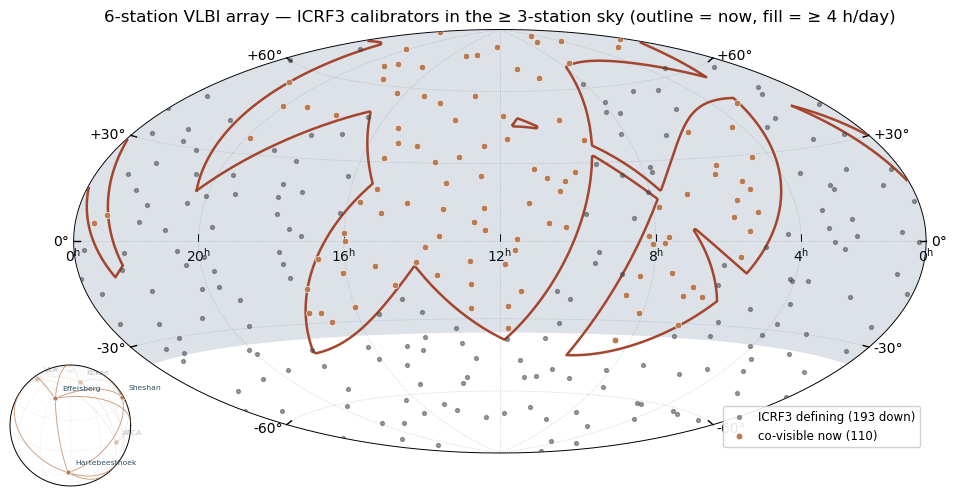

In [20]:
icrf = Table.read("../../examples/data/icrf3_defining.csv")

fig, ax = allsky()
pal = annotation_palette()

# The schedulable band: sky at least 3 of the 6 stations hold for >= 4 h/day.
band = sph.covisibility_duration_band(ax, ARRAY, min_hours=4.0,
                                      el_min=15, min_stations=3)
band.render(facecolor=C[0], alpha=0.18, edgecolor="none")

# The "right now" window: at least 3 stations, at this instant.
now = sph.covisibility_region(ax, ARRAY, TIME, el_min=15, min_stations=3)
now.render(facecolor="none", edgecolor=pal["accent"], lw=1.8)

# One membership call sorts the whole catalog:
up_now = now.contains_points(icrf["ra_deg"], icrf["dec_deg"])
ax.scatter(icrf["ra_deg"][~up_now], icrf["dec_deg"][~up_now],
           transform=ax.get_transform("world"), s=8, color=pal["stars"],
           alpha=0.5, zorder=4, label=f"ICRF3 defining ({(~up_now).sum()} down)")
ax.scatter(icrf["ra_deg"][up_now], icrf["dec_deg"][up_now],
           transform=ax.get_transform("world"), s=22, color=C[1],
           edgecolor=pal["fig_bg"], linewidth=0.4, zorder=5,
           label=f"co-visible now ({up_now.sum()})")

ax.legend(loc="lower right", fontsize=8.5, framealpha=0.9)
ax.set_title("6-station VLBI array — ICRF3 calibrators in the ≥ 3-station sky "
             "(outline = now, fill = ≥ 4 h/day)")

# A locator inset: the array that casts these shadows. On a globe,
# plot_baselines does the whole hidden-line treatment itself — solid arcs on
# the front hemisphere, dotted continuations on the back, and (with
# back_hemisphere_markers=True) the far-side sites drawn ghosted at their
# true positions.
gax = sph.make_planet_frame(111, center_LONdeg=30, center_LATdeg=25,
                            lon_deg_spacing=30, lat_deg_spacing=30,
                            gridcolor="0.6", auto_fontsize=False,
                            tick_style="native")
gax.set_position([0.012, 0.05, 0.22, 0.22])
for coord in gax.coords:                 # a locator globe needs no labels
    coord.set_ticklabel_visible(False)
sph.plot_baselines(gax, {n: (st["lon"], st["lat"]) for n, st in ARRAY.items()},
                   pairs="all", color=C[1], linewidth=0.7, alpha=0.7,
                   marker_color=C[1], marker_size=14,
                   site_label_fontsize=5.5, site_label_color=pal["label"],
                   back_hemisphere_linestyle=":", back_hemisphere_markers=True)
fig.canvas.draw()

Everything composes: the duration band says *what declinations are worth
proposing for*, the instantaneous outline says *what's up right now*, and the
membership test turns 303 calibrators into a schedule shortlist — while the
globe inset reminds us whose horizons did the sculpting, front-hemisphere
stations solid and far-side ones ghosted.

> **Tip:** for your own artists on a globe, the front/back split is
> `orthographic_visibility(lon, lat, lon_0, lat_0)` — a plain boolean mask
> for "which points sit on the front hemisphere as seen from this
> direction."

## 9. Where to go next

| If you want to… | Go to |
|---|---|
| Do set algebra with these regions, or build your own | [Regions & spherical polygons](regions.ipynb) |
| Draw baselines and station networks on a globe | [Globe & planet plotting](globe_plots.ipynb) |
| Style the frames, grids, and tick labels under your fields | [Decorating frames](decorating_frames.ipynb) |
| Plot catalogs with size/color encodings (the full `plot_catalog` tour) | [Catalogs: querying & plotting](catalogs.ipynb) |
| Drive the VSH parameters with live sliders | [Interactive plotting (plotly)](interactive_plotly.ipynb) |
| Animate the co-visible sky over a sidereal day | [Animations](animations.ipynb) |
| The compact reference version of this material | [Vectors & sky kinematics guide](../guide/vectors.md) |

### Data and references

- Perryman, M. A. C., et al. 1997, A&A, 323, L49 — *The Hipparcos Catalogue*:
  the bright-star positions and proper motions used throughout (VizieR I/239).
- Charlot, P., et al. 2020, A&A, 644, A159 — the **ICRF3** paper: the
  defining-source list of §8, and the VSH parameter convention followed here.
- Mignard, F., & Klioner, S. 2012, A&A, 547, A59 — the VSH formalism for
  analyzing astrometric catalogs.
- Titov, O., & Lambert, S. 2013, A&A, 559, A95 — the VLBI measurement of the
  secular aberration drift (§1).
- Gaia Collaboration (Klioner, S. A., et al.) 2021, A&A, 649, A9 — the Gaia
  EDR3 measurement of the solar-system acceleration, 5.05 ± 0.35 μas/yr (§1).
- Schönrich, R., Binney, J., & Dehnen, W. 2010, MNRAS, 403, 1829 — the modern
  solar motion with respect to the local standard of rest (§6).